## Goal and how to run

Download the complete `.ipynb`. In VibeIt Studio's file browser use **+ → Import from Files**, then open it. Run code cells from top to bottom. Saved charts show actual executed results; rerunning recomputes them from embedded data.

This lesson assumes basic Python knowledge. Read each method and caption before changing parameters. AI exercises are optional; no AI account is needed for the core workflow. Data lives in notebook metadata, so there is no companion data download. Keep the notebook saved in the active working folder.

Your goal is to understand the research question, execute transparent calculations, check the results, and state the limits of the conclusion.

## Setup and parameters

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from scipy.signal import welch, butter, sosfiltfilt
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='ph05-gw150914'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### Load the embedded snapshot

The loader locates this notebook in the working folder by recipe ID and SHA-256, then decompresses and verifies the data. Renaming the file does not change its identity. If loading fails, check the working folder and saved file. Metadata travels with `.ipynb` save/export; copying code to a standalone `.py` does not copy the dataset.

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'gw150914': '4068109f074163cc9a5b99edc94606ede7862f9b5907e7903c307fe7fd713edf'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['gw150914']


### Read the method functions

The full implementations appear below. They use the listed bundled packages and standard library; no cookbook helper module is imported at runtime. Inspect input requirements and return values. If you change an algorithm, its checks must still pass.

### Data and model boundary

Pendulum, oscillator, projectile and heat trajectories are declared numerical models, not laboratory measurements. The gravitational acceleration is the conventional standard g0 when used. GW150914 uses actual frozen detector strain and published event timing; a filtered curve is not an independent significance or source-parameter analysis. Blackbody curves assume an ideal emitter.

## Steps

### 1. Audit actual strain samples and event timing

The embedded GWOSC snapshot is H1, 4096 samples/s, 32 seconds. Strain is dimensionless. Plot time relative to the published event GPS; the event label comes from the catalog, not from thresholding this plot.

Release: GW150914 v3 / 4KHZ_R1 ; detector: H1 ; samples: 131072 ; rate: 4096 Hz


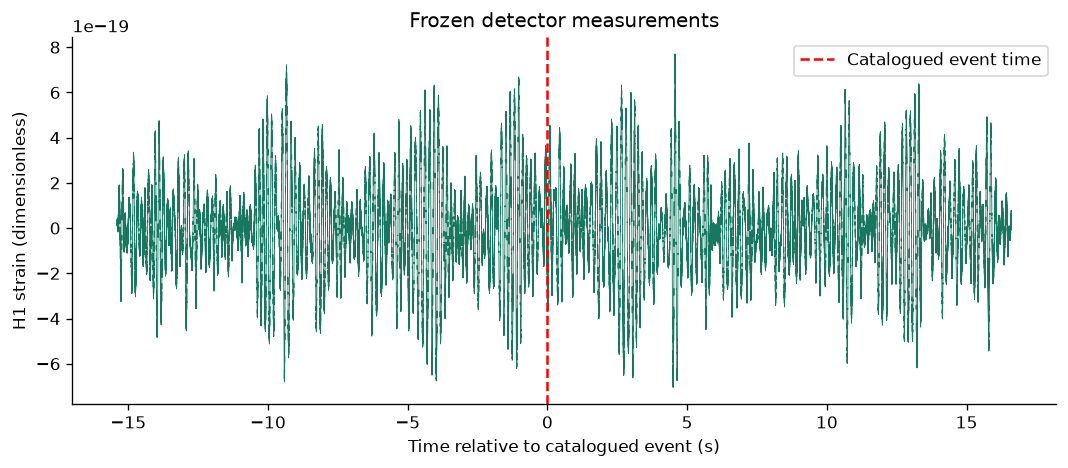

In [3]:
gw=snapshot("gw150914");strain=np.asarray(gw["strain"],float);fs=gw["sample_rate"]
assert len(strain)==fs*gw["duration"] and np.isfinite(strain).all()
relative_time=gw["gps_start"]+np.arange(len(strain))/fs-gw["event_gps"]
centered=strain-strain.mean()
print("Release:",gw["version"],"; detector:",gw["detector"],"; samples:",len(strain),"; rate:",fs,"Hz")
fig,ax=plt.subplots(figsize=(9,4));ax.plot(relative_time,centered,lw=.5)
ax.axvline(0,color="red",linestyle="--",label="Catalogued event time")
ax.set(xlabel="Time relative to catalogued event (s)",ylabel="H1 strain (dimensionless)",title="Frozen detector measurements");ax.legend();plt.tight_layout();plt.show()


### 2. Estimate amplitude spectral density

Welch averages overlapping tapered segments. sqrt(PSD) has units strain/sqrt(Hz); it is not the same quantity as a raw FFT amplitude. Source data is downsampled, so avoid interpreting near-Nyquist details as an independently calibrated high-frequency result.

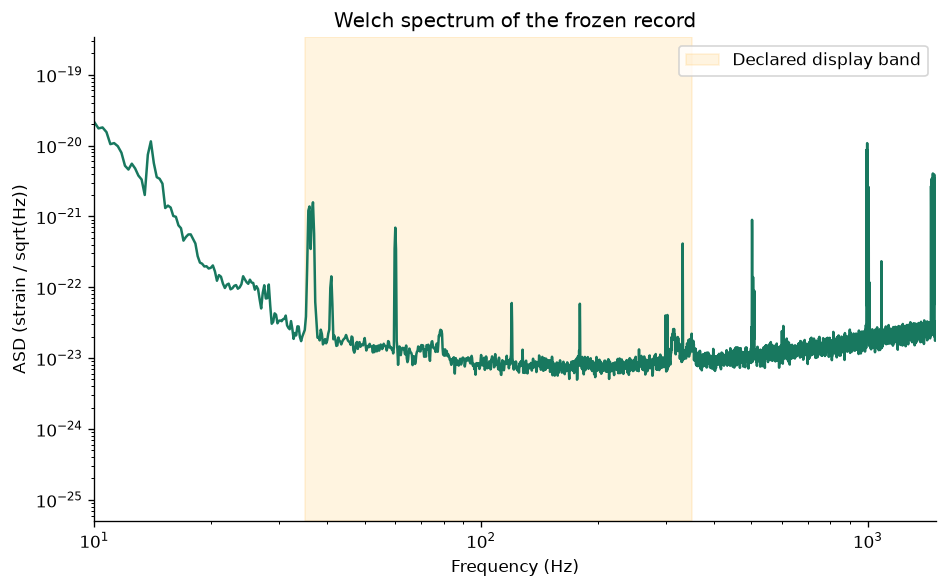

In [4]:
frequency,psd=welch(centered,fs=fs,nperseg=fs*4,noverlap=fs*2,scaling="density")
positive=frequency>0
fig,ax=plt.subplots(figsize=(8,5));ax.loglog(frequency[positive],np.sqrt(psd[positive]))
ax.axvspan(35,350,color="orange",alpha=.12,label="Declared display band")
ax.set(xlim=(10,1500),xlabel="Frequency (Hz)",ylabel="ASD (strain / sqrt(Hz))",title="Welch spectrum of the frozen record");ax.legend();plt.tight_layout();plt.show()


### 3. Apply a declared acausal display filter

The fourth-order Butterworth 35–350 Hz band-pass is applied forward and backward. This is zero-phase offline display processing and uses future samples within the record. A single detector’s filtered trace does not establish false-alarm probability or reproduce the published detection pipeline.

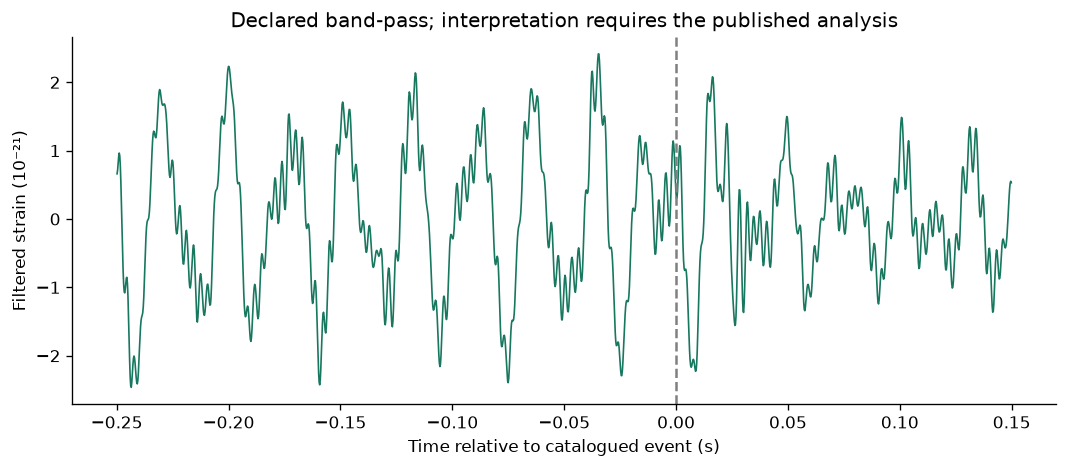

In [5]:
sos=butter(4,[35,350],btype="bandpass",fs=fs,output="sos")
filtered=sosfiltfilt(sos,centered)
window=(relative_time>=-.25)&(relative_time<=.15)
fig,ax=plt.subplots(figsize=(9,4));ax.plot(relative_time[window],1e21*filtered[window],lw=1)
ax.axvline(0,color="gray",linestyle="--")
ax.set(xlabel="Time relative to catalogued event (s)",ylabel="Filtered strain (10⁻²¹)",title="Declared band-pass; interpretation requires the published analysis");plt.tight_layout();plt.show()


### 4. Audit spectral normalization and export

Use Parseval’s identity for the full-record real FFT as a separate normalization check. That identity is distinct from the averaged Welch PSD. Export the filter band and event metadata with every derived series.

In [6]:
transform=np.fft.rfft(centered);squared=np.abs(transform)**2
fft_variance=(squared[0]+squared[-1]+2*squared[1:-1].sum())/len(centered)**2
assert np.isclose(fft_variance,np.mean(centered**2),rtol=1e-12,atol=0)
assert np.isfinite(filtered).all() and np.all(psd>=0)
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
pd.DataFrame({"relative_time_s":relative_time,"centered_strain":centered,"filtered_strain":filtered}).to_csv(OUTPUT_DIR/"strain-display.csv",index=False)
pd.DataFrame({"frequency_Hz":frequency,"PSD_strain_squared_per_Hz":psd}).to_csv(OUTPUT_DIR/"welch-spectrum.csv",index=False)
(OUTPUT_DIR/"processing.json").write_text(json.dumps({"detector":gw["detector"],"release":gw["version"],"event_GPS":gw["event_gps"],"sample_rate_Hz":fs,"band_Hz":[35,350],"filter":"4th-order Butterworth SOS, forward/backward","inference":"display processing; no independent detection significance"},indent=2))
print("Parseval check passed; source credit: GWOSC, LIGO, Virgo and KAGRA. Exports:",OUTPUT_DIR)


Parseval check passed; source credit: GWOSC, LIGO, Virgo and KAGRA. Exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/ph05-gw150914


## Exercises and reference explanation

1. Distinguish PSD, ASD and FFT amplitude units.
2. Why is forward/backward filtering not real-time processing?

**Reference explanation.** ASD is sqrt(PSD), with strain/sqrt(Hz) units. Acausal filtering reads future record samples; a displayed waveform alone is not a significance calculation.

Keep a copy before changing parameters. Compare old and new figures and record which inputs, calculations and conclusions changed.

## Optional AI coding exercises

Open the current notebook in VibeIt's Coding Agent and ask it to read the relevant cells. The core lesson does not depend on AI access; see the Help Center for provider and account setup.

**Prompt 1**

> Using NumPy/SciPy/Matplotlib, compare 30–300 and 35–350 Hz bands while preserving the same original strain and declared settings.

**Prompt 2**

> With the same packages, add a filter-magnitude response and mark the selected band; retain the FFT Parseval check.

**Human acceptance.** Preserve all 131072 samples, source timing and credit, finite outputs and explicit acausal/display interpretation.

Review the edited source, then manually run affected cells and subsequent checks. Ask the assistant to explain the purpose, packages and data provenance of its changes, and reconcile that explanation with actual output.

## Optional online extension

The network action below is disabled by default. It reports a database version/source without replacing the core data. To refresh data, save a separate experimental version and record the new URL, database release, retrieval date and SHA-256. New results require rerunning and validation.

In [7]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## Sources, snapshots and next steps

- [GWOSC GW150914 v3 event metadata](https://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/) — CC BY 4.0; acknowledge GWOSC, LIGO, Virgo and KAGRA; GWTC-1 DOI 10.7935/82H3-HH23; retrieved 2026-10-09. SHA-256 `1ce014e3277cc6ef491daa48250465eefda026f2b974d2a15bb8c6ea5596e37e`.
  Preserve event GPS, release and strain download parameters; event catalog values are not recomputed detection significance.

- [GWOSC H1 32 second strain](https://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/H-H1_GWOSC_4KHZ_R1-1126259447-32.txt.gz) — CC BY 4.0; credit GWOSC and collaborations; DOI 10.7935/82H3-HH23; retrieved 2026-10-09. SHA-256 `fefe8717306109460b6c9cff74da6beb9e80ee624824b4b09bdd2c54ce9b4dfc`.
  Decompress original ASCII data and parse all 131072 strain samples; preserve GPS start and sampling rate.


**Next steps.** Transfer these methods to your own public or authorized data while retaining input checks, recorded parameters and result validation. Document the new experimental design and method limits; this example does not validate a new experiment. Full data licenses and generation instructions accompany the cookbook.